### Cell 1 — Gradient của MSE (Calculus) + kiểm chứng số

**Mục tiêu:** nhắc lại đạo hàm/gradient và suy ra gradient của **MSE** trong hồi quy tuyến tính.

**Định nghĩa MSE**
Với ma trận đặc trưng \(X \in \mathbb{R}^{n\times p}\), tham số \(\beta \in \mathbb{R}^{p\times 1}\) và mục tiêu \(y \in \mathbb{R}^{n\times 1}\):
  $$
  \mathrm{MSE}(\beta)=\frac{1}{n}\,\|y - X\beta\|^2
  =\frac{1}{n}(y - X\beta)^\top(y - X\beta).
  $$

- Gradient theo \(\beta\):
- Dùng quy tắc vi phân ma trận (hoặc viết dạng trace) ta có:
  $$
  \nabla_{\beta}\,\mathrm{MSE}(\beta)
  = \frac{2}{n}\,X^\top\big(X\beta - y\big).
  $$

**Trong cell này**
- Dùng **SymPy** (trace + `derive_by_array`) để xuất biểu thức gradient ở trên.
- **Kiểm chứng số**: so sánh thành phần gradient giải tích với **sai phân hữu hạn** → khớp gần như tuyệt đối.
- Ý nghĩa: khi \(\nabla_{\beta}\,\mathrm{MSE}=0\) ta thu được nghiệm **OLS** từ phương trình chuẩn \(X^\top X\,\beta = X^\top y\).


In [ ]:
# CELL 1 — Derivatives & Gradient of MSE: symbolic derivation + numeric check
import numpy as np
import sympy as sp

sp.init_printing(use_unicode=True)

# --- 1) Symbolic derivation for MSE gradient (fixed: use Trace + derive_by_array) ---
import sympy as sp
sp.init_printing(use_unicode=True)

n, p = sp.symbols('n p', positive=True, integer=True)
X    = sp.MatrixSymbol('X', n, p)
y    = sp.MatrixSymbol('y', n, 1)
beta = sp.MatrixSymbol('beta', p, 1)

res  = X*beta - y
MSE  = (1/n) * sp.Trace(res.T * res)            # scalar via trace
grad_MSE = sp.simplify(sp.derive_by_array(MSE, beta))  # d/d(beta) as a p×1 array

print("Symbolic gradient ∇_β MSE =")
sp.pprint(grad_MSE)   # kỳ vọng: (2/n) * X.T * (X*beta - y)

# --- 2) Numeric sanity check ---
rng = np.random.default_rng(0)
n_val, p_val = 200, 3
X_val = rng.normal(size=(n_val, p_val))
beta_true = np.array([[1.5], [-2.0], [0.7]])
y_clean = X_val @ beta_true
y_val = y_clean + rng.normal(scale=0.5, size=(n_val,1))

beta_guess = rng.normal(size=(p_val,1))

def mse(beta_num):
    r = y_val - X_val @ beta_num
    return (r.T @ r).item() / n_val

def grad_mse(beta_num):
    return (2.0 / n_val) * (X_val.T @ (X_val @ beta_num - y_val))

# finite-difference check for first coordinate
eps = 1e-6
g = grad_mse(beta_guess)
e0 = np.zeros_like(beta_guess); e0[0,0] = 1.0
fd = (mse(beta_guess + eps*e0) - mse(beta_guess - eps*e0)) / (2*eps)

print("\nNumeric gradient (analytic) first coord:", float(g[0,0]))
print("Numeric gradient (finite-diff) first coord:", float(fd))
print("MSE at beta_guess:", mse(beta_guess))


Symbolic gradient ∇_β MSE =
2  T           
─⋅X ⋅(-y + X⋅β)
n              

Numeric gradient (analytic) first coord: -4.461412393306804
Numeric gradient (finite-diff) first coord: -4.461412395961872
MSE at beta_guess: 12.916513838102633


### Cell 2 — Gradient Descent tối ưu MSE (liên hệ đạo hàm ↔ tối ưu)
- **Mục tiêu:** Dùng \(\nabla \mathrm{MSE}\) để **tối thiểu hoá** MSE và so sánh với nghiệm **OLS closed-form**.
- **Thiết lập:** Thêm intercept, khởi tạo \(\beta\), cập nhật \(\beta \leftarrow \beta - \eta \nabla\mathrm{MSE}\) với **early stopping** (‖∇MSE‖/‖Δβ‖ nhỏ).
- **Kết quả:** \(\beta_{\text{GD}}\) hội tụ trùng \(\beta_{\text{OLS}}\); MSE giảm nhanh, đồ thị **MSE** và **‖β−β_OLS‖** đi về 0.
- **Thông điệp:** Đạo hàm cung cấp hướng cập nhật → thuật toán tối ưu (GD) tìm nghiệm giống công thức đóng.


β_OLS : [-0.0181  1.455  -2.0481  0.7265]
β_GD  : [-0.0181  1.455  -2.0481  0.7265]
MSE(OLS) : 0.25004004303351823
MSE(GD)  : 0.2500400430337598
Iter: 163 | ||grad||: 9.97e-07 | step: 4.99e-08


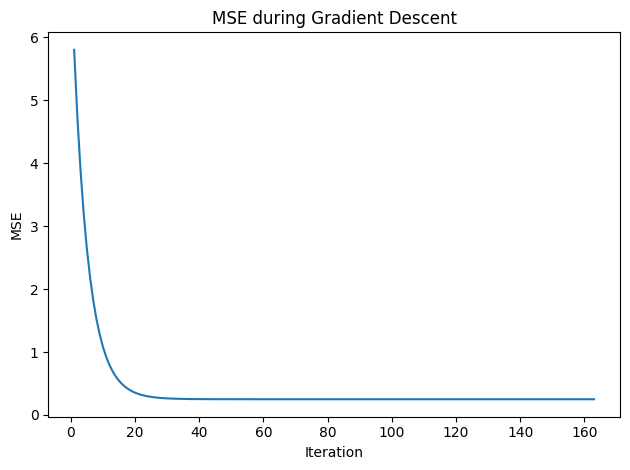

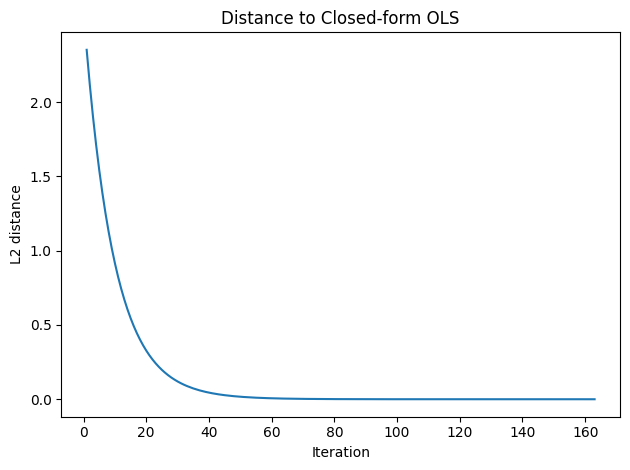

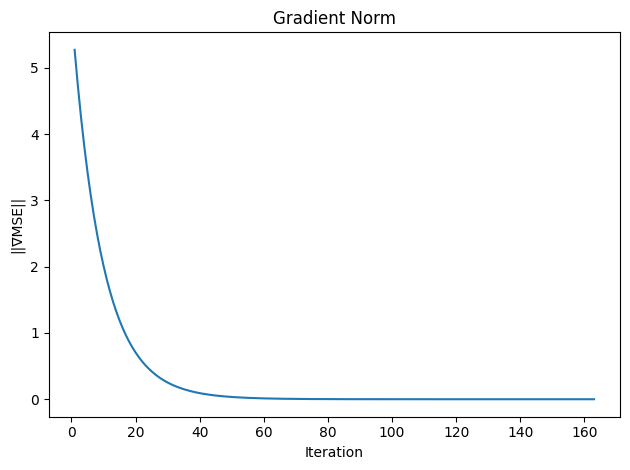

In [ ]:
# CELL 2 — Gradient Descent tối ưu MSE (optimized)
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# Dùng lại X_val, y_val nếu đã có; nếu chưa thì tạo nhanh
if 'X_val' not in globals():
    rng = np.random.default_rng(0)
    n_val, p_val = 200, 3
    X_val = rng.normal(size=(n_val, p_val))
    beta_true = np.array([[1.5], [-2.0], [0.7]])
    y_val = X_val @ beta_true + rng.normal(scale=0.5, size=(n_val,1))

# Thêm intercept
Xb = np.column_stack([np.ones((X_val.shape[0],1)), X_val])  # (n, p+1)
n = Xb.shape[0]

def mse(beta_num):
    r = y_val - Xb @ beta_num
    return float((r.T @ r).item() / n)  # .item() tránh DeprecationWarning

def grad_mse(beta_num):
    return (2.0 / n) * (Xb.T @ (Xb @ beta_num - y_val))

# Closed-form OLS để so sánh
beta_ols = np.linalg.inv(Xb.T @ Xb) @ (Xb.T @ y_val)
mse_ols  = mse(beta_ols)

# --------- Gradient Descent (với early stopping) ----------
beta = np.zeros_like(beta_ols)  # khởi tạo
eta  = 0.05                     # learning rate cố định (đủ cho minh hoạ)
max_steps = 2000
tol_grad  = 1e-6
tol_step  = 1e-9

hist_mse, hist_gnorm, hist_step, hist_dist = [], [], [], []

for t in range(1, max_steps+1):
    g = grad_mse(beta)
    gnorm = float(np.linalg.norm(g))
    beta_new = beta - eta * g
    step_norm = float(np.linalg.norm(beta_new - beta))

    hist_mse.append(mse(beta_new))
    hist_gnorm.append(gnorm)
    hist_step.append(step_norm)
    hist_dist.append(float(np.linalg.norm(beta_new - beta_ols)))

    beta = beta_new

    # Early stopping theo tiêu chuẩn
    if gnorm < tol_grad or step_norm < tol_step:
        # pad cho đủ chiều trục nếu cần
        break

print("β_OLS :", beta_ols.ravel())
print("β_GD  :", beta.ravel())
print("MSE(OLS) :", mse_ols)
print("MSE(GD)  :", hist_mse[-1])
print(f"Iter: {len(hist_mse)} | ||grad||: {hist_gnorm[-1]:.2e} | step: {hist_step[-1]:.2e}")

# --------- Plots ----------
plt.figure()
plt.plot(range(1, len(hist_mse)+1), hist_mse)
plt.title("MSE during Gradient Descent")
plt.xlabel("Iteration"); plt.ylabel("MSE")
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(range(1, len(hist_dist)+1), hist_dist)
plt.title("Distance to Closed-form OLS")
plt.xlabel("Iteration"); plt.ylabel("L2 distance")
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(range(1, len(hist_gnorm)+1), hist_gnorm)
plt.title("Gradient Norm")
plt.xlabel("Iteration"); plt.ylabel("||∇MSE||")
plt.tight_layout(); plt.show()


### Cell 3 — Từ giải tích đến tối ưu hiệu năng chiến lược (Sharpe-like)
- **Mục tiêu:** Minh hoạ cách dùng đạo hàm/gradient để **tối ưu tham số chiến lược** (ở đây là ngưỡng `θ`).
- **Thiết kế:** Biến vị thế thành hàm **trơn** \( s_\theta = \tanh(k(z-\theta)) \) (tránh ngưỡng rời rạc), mục tiêu tối đa hoá **Sharpe-like** \( J(\theta) \).
- **Tối ưu:** Dùng **gradient-ascent** (ước lượng đạo hàm bằng **finite difference**) để cập nhật `θ`.
- **Kết quả (ví dụ):** \(J\) tăng từ ~0.1491 → ~0.1498, tìm được \(\theta^\*\approx 0.074\).
- **Ý nghĩa:** Khi mục tiêu hiệu năng có thể làm trơn, ta liên kết **giải tích (đạo hàm)** với **tối ưu hoá tham số** của chiến lược.



Start  J: 0.1491261673348905
Final  J: 0.1498349534391131
Theta*  : 0.07413130245760569


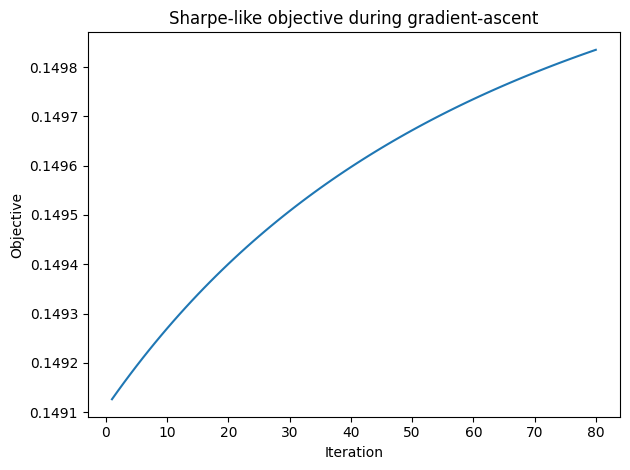

In [ ]:
# CELL 3 — Calculus → Optimization for Strategy Performance (maximize smooth Sharpe-like)

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# Giả lập một tín hiệu "z" và chuỗi lợi nhuận "ret" có tương quan nhẹ với z
T = 1000
z = rng.normal(size=T).cumsum() / 50.0                    # tín hiệu trơn
ret = 0.002 * np.tanh(z) + rng.normal(scale=0.01, size=T) # ret phụ thuộc z một chút

# Position mượt hoá: s_theta = tanh(k*(z - theta))  → tránh hàm không trơn
k = 3.0    # độ dốc
eps = 1e-4 # bước vi phân số cho gradient
lr  = 0.1  # learning rate (ascent)
steps = 80

def sharpe_like(theta):
    s = np.tanh(k * (z - theta))
    pos = np.roll(s, 1)  # chống lookahead
    pos[0] = 0.0
    pnl = pos * ret
    mu, sd = pnl.mean(), pnl.std(ddof=0)
    return 0.0 if sd == 0 else mu / sd

# Gradient-ascent theo theta: dJ/dtheta ≈ [J(theta+eps) - J(theta-eps)]/(2eps)
theta = 0.0
hist_J, hist_theta = [], []

for t in range(steps):
    J = sharpe_like(theta)
    g = (sharpe_like(theta + eps) - sharpe_like(theta - eps)) / (2*eps)
    theta = theta + lr * g          # ascent
    hist_J.append(J); hist_theta.append(theta)

print("Start  J:", hist_J[0])
print("Final  J:", hist_J[-1])
print("Theta*  :", theta)

# Plot quá trình tối ưu
plt.figure()
plt.plot(range(1, len(hist_J)+1), hist_J)
plt.title("Sharpe-like objective during gradient-ascent")
plt.xlabel("Iteration"); plt.ylabel("Objective")
plt.tight_layout(); plt.show()
